In [1]:
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from tqdm import trange, tqdm

from Datasets.datasets import stratified_split, DataLoader
from Datasets.mnist_dataloader import MNIST_DataLoader
from Models.sequential import Sequential_Model
from Layers.linear import LinearLayer
from Layers.conv import Conv2DLayer
from Activations.relu import relu
from Activations.sigmoid import sigmoid
from Loss_Func.log_loss import log_loss
from Metrics import accuracy, f1_score
from Layers.flatten import Flatten
from Metrics.plot_metric import plot_metric

In [2]:
mnist_dataloader = MNIST_DataLoader("./Datasets/MNIST/")
X_train, y_train, X_test, y_test = mnist_dataloader.load_data()

In [3]:
X_train, y_train, X_val, y_val = stratified_split(X_train, y_train, val_split=0.2, seed=42)

In [4]:
c1, c2 = 0, 1

def filter_dataset(X, y, c1, c2):
    filtered_idx = (y==c1) | (y==c2)

    return X[filtered_idx], y[filtered_idx]

X_train, y_train = filter_dataset(X_train, y_train, c1, c2)
X_val, y_val = filter_dataset(X_val, y_val, c1, c2)
X_test, y_test = filter_dataset(X_test, y_test, c1, c2)

In [5]:
X_train.shape, X_val.shape, X_test.shape

((10131, 28, 28), (2534, 28, 28), (2115, 28, 28))

Correct label is: 0


(<matplotlib.image.AxesImage at 0x1336ad550>, None)

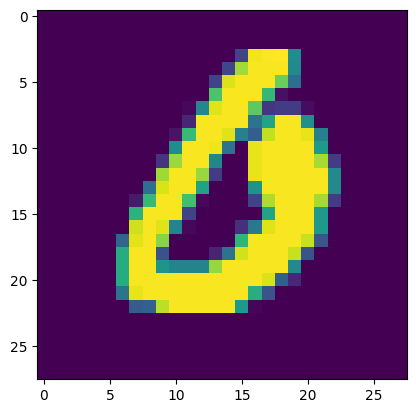

In [6]:
idx = 0
plt.imshow(X_train[idx]), print(f"Correct label is: {y_train[idx]}")

In [7]:
X_train = torch.unsqueeze(torch.tensor(X_train), 1)
y_train = torch.tensor(y_train==c1, dtype=torch.int8)

X_val = torch.unsqueeze(torch.tensor(X_val), 1)
y_val = torch.tensor(y_val==c1, dtype=torch.int8)

In [8]:
batch_size = 258
train_dataloader = DataLoader(X_train, y_train, batch_size)
val_dataloader = DataLoader(X_val, y_val, batch_size)

In [9]:
model = Sequential_Model(
            [Conv2DLayer(window_size=(11,11), channels_in=1, channels_out=4),
             relu(),
             Conv2DLayer(window_size=(7,7), channels_in=4, channels_out=4),
             relu(),
             Flatten(),
             LinearLayer(12*12*4,1),
             sigmoid()], log_loss
        )
model.to("cpu")

In [10]:
epochs = 10
loss_history = []
acc_history = []
f1_history = []

val_loss_history = []
val_acc_history = []
val_f1_history = []

for i in range(epochs):
    print(f"Running epoch: {i}\n")
    for [x_train_batch, y_train_batch] in tqdm(train_dataloader):
        preds = model.forward_pass(x_train_batch)
        loss = model.loss_calc(y_train_batch, preds)
        model.backward_pass()
        model.step(1e-5)
        
        loss_history.append(loss)
        acc = accuracy(y_train_batch, preds)
        acc_history.append(acc)
        f1 = f1_score(y_train_batch, preds)
        f1_history.append(f1)

        print(f"Loss:{loss}, acc:{acc}, F1:{f1}")

    print(f"Running validation\n")
    for [x_val_batch, y_val_batch] in tqdm(val_dataloader):
        preds = model.forward_pass(x_val_batch)
        loss = model.loss_calc(y_val_batch, preds)

        val_loss_history.append(loss)
        acc = accuracy(y_val_batch, preds)
        val_acc_history.append(acc)
        f1 = f1_score(y_val_batch, preds)
        val_f1_history.append(f1)

        print(f"Loss:{loss}, acc:{acc}, F1:{f1}")

Running epoch: 0



1it [00:00,  6.71it/s]

Loss:8.2000150680542, acc:0.5503876209259033, F1:0.03333333507180214


2it [00:00,  6.32it/s]

Loss:8.668510437011719, acc:0.5193798542022705, F1:0.04615384712815285


...

Loss:0.8860365748405457, acc:0.9147287011146545, F1:0.9090909361839294
Loss:1.0636341571807861, acc:0.934108555316925, F1:0.9230769276618958
Loss:1.5914703607559204, acc:0.895348846912384, F1:0.8941176533699036
Loss:1.1313388347625732, acc:0.9147287011146545, F1:0.8981481194496155


6it [00:00, 24.78it/s]

Loss:1.4479575157165527, acc:0.9108527302742004, F1:0.9068825840950012


10it [00:00, 24.58it/s]

Loss:1.3281795978546143, acc:0.9108527302742004, F1:0.9004328846931458
Loss:1.0692641735076904, acc:0.930232584476471, F1:0.9279999732971191
Loss:1.1454136371612549, acc:0.9292452931404114, F1:0.920634925365448


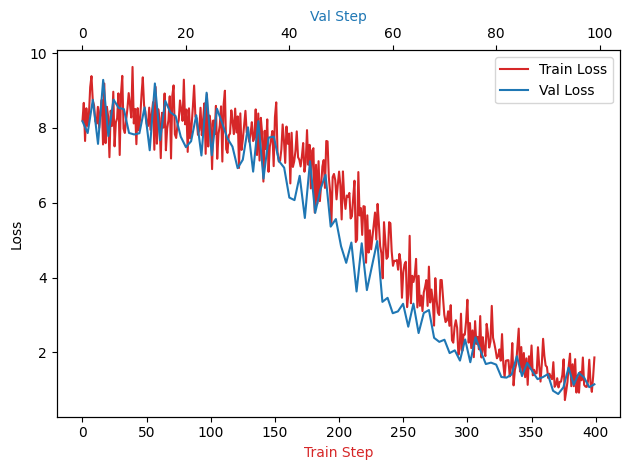

In [11]:
plot_metric(loss_history, "Train Loss", "Loss", "Loss", val_loss_history, "Val Loss")

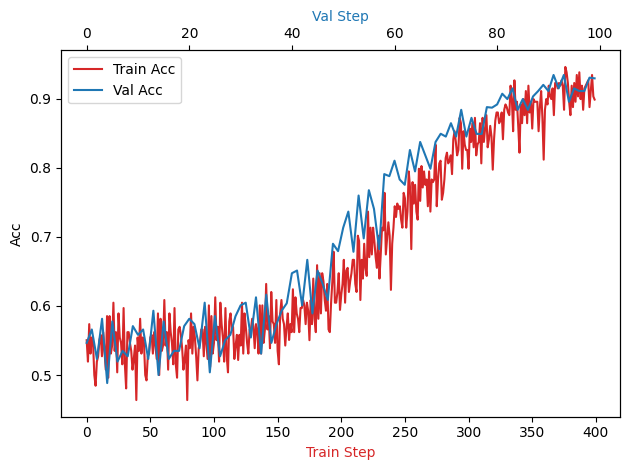

In [12]:
plot_metric(acc_history, "Train Acc", "Acc", "Acc", val_acc_history, "Val Acc")

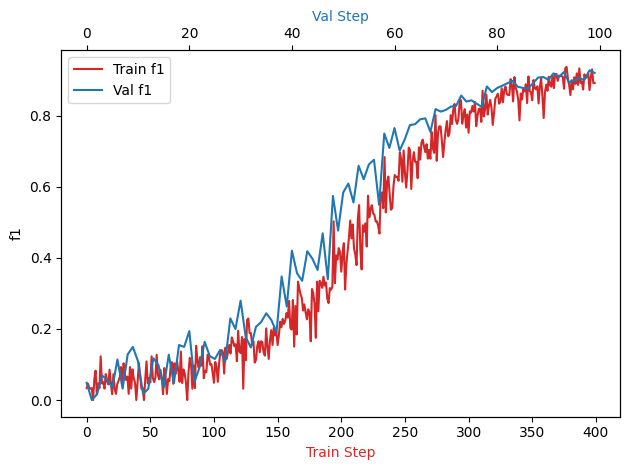

In [13]:
plot_metric(f1_history, "Train f1", "f1", "f1", val_f1_history, "Val f1")